In [ ]:
from utils.model_analysis import get_masked_prediction_mlp, get_masked_prediction_map, plot_seasonal_analysis_all
from utils.plot_map import plot_maps_2x2
from models.unext import CyclicHorizontalPadding2D
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from utils.data_loader import load_as_maps
from utils.ocean_basins import get_region

In [2]:
mlp_path = "../../outputs/mlp/best"
unet_path = "../../outputs/u-net/best"
unext_path = "../../outputs/u-next/best"
dataset_ids = ["exp8"]#, "exp8"]
start_year = 1958
end_year = 2018

# for dataset_id in dataset_ids:
#     targets, mlp_pred = get_masked_prediction_mlp(mlp_path, dataset_id, start_year=start_year, end_year=end_year, target_index=3)
#     _, unet_pred = get_masked_prediction_map(unet_path, dataset_id, start_year=start_year, end_year=end_year, target_index=3)
#     _, unext_pred = get_masked_prediction_map(unext_path, dataset_id, start_year=start_year, end_year=end_year, target_index=3)

#     predictions_dict = {
#         "MLP": mlp_pred,
#         "UNet": unet_pred,
#         "UNeXt": unext_pred,
#         "Swin": unext_pred
#     }

#     mean_error_dict = {
#          "MLP": [],
#         "UNet": [],
#         "UNeXt": [],
#         "Swin": []
#     }

#     rmse_dict = {
#          "MLP": [],
#         "UNet": [],
#         "UNeXt": [],
#         "Swin": []
#     }

#     for key in predictions_dict:

#         absolute_error = np.abs(predictions_dict[key] - targets)
#         mean_error_dict[key] = np.mean(absolute_error, axis=0)
#         squared_error = (predictions_dict[key] - targets) ** 2
#         rmse_dict[key] = np.sqrt(np.mean(squared_error, axis=0)) 

#     plot_maps_2x2(mean_error_dict, "../../outputs/plots/error_maps",dataset_id+"me")
#     plot_maps_2x2(rmse_dict, "../../outputs/plots/error_maps",dataset_id+"rmse")

In [ ]:


X_test, Y_test = load_as_maps(start_year=2017, end_year=2018, datasets=["exp1"],target_index=3)
map_mask = X_test[0,:,:, 10] == 1

In [28]:


start_year = 2013
end_year = 2018
dataset_ids = ["exp1","exp5","exp6","exp7"] #["exp1","exp5","exp6","exp7"]["exp3","exp8"]
# for dataset_id in dataset_ids:
#     features, targets = load_as_maps(start_year=start_year, end_year=end_year, datasets=[dataset_id],target_index=3)

#     y_true = targets[:, map_mask].flatten()

#     print(dataset_id)
#     mse_zero_model = np.mean(y_true**2)
#     print("MSE of zero model:", mse_zero_model)

#     mae_zero_model = np.mean(np.abs(y_true))
#     print("MAE of zero model:", mae_zero_model)

# features, targets = load_as_maps(start_year=start_year, end_year=end_year, datasets=[dataset_id],target_index=3)

for dataset_id in dataset_ids:

    targets, mlp_pred = get_masked_prediction_mlp(mlp_path, dataset_id, start_year=start_year, end_year=end_year, target_index=3)
    _, unet_pred = get_masked_prediction_map(unet_path, dataset_id, start_year=start_year, end_year=end_year, target_index=3)
    # _, unext_pred = get_masked_prediction_map(unext_path, dataset_id, start_year=start_year, end_year=end_year, target_index=3)

    # map_mask = features[:,:,:, 10] == 1

    predictions_dict = {
        "MLP": mlp_pred,
        "UNet": unet_pred,
        # "UNeXt": unext_pred,
    }

    mean_error_dict = {
         "MLP": [],
        "UNet": [],
        # "UNeXt": [],
    }

    rmse_dict = {
         "MLP": [],
        "UNet": [],
        # "UNeXt": [],
    }

    regions = ['ARCTIC', 'NORTH_ATLANTIC', 'EQ_PACIFIC', 'SOUTHERN_OCEAN']

    for region in regions:
        region_targets = get_region(targets, region)
        region_pred = get_region(unet_pred, region)
        region_mask = get_region(np.expand_dims(map_mask,axis=0), region).squeeze(axis=0)

        region_pred = region_pred[:,region_mask].reshape(-1)
        region_targets = region_targets[:,region_mask].reshape(-1)

        mse = mean_squared_error(region_pred, region_targets)
        mae = mean_absolute_error(region_pred, region_targets)

        print(region)
        print("MAE: " + f"{mae:.3f}" + " MSE: " + f"{mse:.3f}")


    for key in predictions_dict:

        absolute_error = np.abs(predictions_dict[key] - targets)
        mean_error_dict[key] = np.mean(absolute_error, axis=0)
        squared_error = (predictions_dict[key] - targets) ** 2
        rmse_dict[key] = np.sqrt(np.mean(squared_error, axis=0))



    # plot_maps_2x2(mean_error_dict, "../../outputs/plots/error_maps",dataset_id+"me")

    all_values = []
    all_mae_values = []

    for key in rmse_dict:
        rmse_map = rmse_dict[key][map_mask]        # shape (167, 360)
        rmse_values = rmse_map.flatten() # 1D
        all_values.append(rmse_values)

        mae_map = rmse_dict[key][map_mask]         # shape (167, 360)
        mae_values = mae_map.flatten() # 1D
        all_mae_values.append(mae_values)

    all_values = np.concatenate(all_values)
    all_mae_values = np.concatenate(all_mae_values)

    # print(dataset_id)
    # print(np.percentile(all_values, 95))

    # plot_maps_2x2(rmse_dict, "../../outputs/plots/error_maps",dataset_id+"rmse", cmap='Wistia',vmax=np.percentile(all_values, 95))
    # plot_maps_2x2(mean_error_dict, "../../outputs/plots/error_maps",dataset_id+"mae", cmap='Wistia',vmax=np.percentile(all_mae_values, 95))


529/529 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 290ms/step
ARCTIC
MAE: 0.101 MSE: 0.069
NORTH_ATLANTIC
MAE: 0.206 MSE: 0.092
EQ_PACIFIC
MAE: 0.108 MSE: 0.023
SOUTHERN_OCEAN
MAE: 0.279 MSE: 0.167
529/529 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 289ms/step
ARCTIC
MAE: 0.053 MSE: 0.020
NORTH_ATLANTIC
MAE: 0.134 MSE: 0.043
EQ_PACIFIC
MAE: 0.083 MSE: 0.015
SOUTHERN_OCEAN
MAE: 0.219 MSE: 0.105
529/529 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 289ms/step
ARCTIC
MAE: 0.020 MSE: 0.002
NORTH_ATLANTIC
MAE: 0.063 MSE: 0.009
EQ_PACIFIC
MAE: 0.030 MSE: 0.002
SOUTHERN_OCEAN
MAE: 0.106 MSE: 0.025
529/529 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 279ms/step
ARCTIC
MAE: 0.021 MSE: 0.002
NORTH_ATLANTIC
MAE: 0.061 MSE: 0.008
EQ_PACIFIC
MAE: 0.029 MSE: 0.002
SOUTHERN_OCEAN
MAE: 0.098 MSE: 0.021


In [5]:
from utils.plot_map import plot_map
# plot_maps_2x2(rmse_dict, "../../outputs/plots/error_maps",dataset_id+"rmse-pres", title=dataset_id, cmap='Wistia',vmax=0.55)

for key in mean_error_dict:
    mae_map = rmse_dict[key]
    mae_values = mae_map.flatten()
    plot_map(mae_map,"../../outputs/plots/error_maps",dataset_id,"dataset_id_"+ key,vmax=np.percentile(mae_values, 95),cmap="Wistia")

Min: 0.0
Max: 2.022292668356208
Mean: 0.07922343144202741
Median: 0.060964571667062276
Std: 0.08565000196615549
50th percentile: 0.060964571667062276
75th percentile: 0.1233639637245468
90th percentile: 0.19135750982271507
95th percentile: 0.2355012174074402
99th percentile: 0.33960936291773536


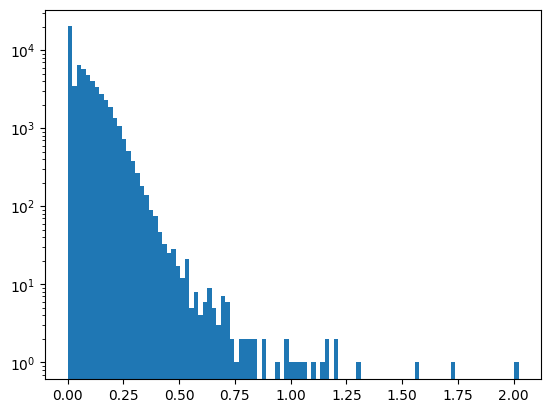

Min: 0.0
Max: 1.434569381008519
Mean: 0.05591432332524423
Median: 0.04151903582506722
Std: 0.06294942737997411
50th percentile: 0.04151903582506722
75th percentile: 0.08423412261710576
90th percentile: 0.140916157245563
95th percentile: 0.17277477254949675
99th percentile: 0.2446229688016139


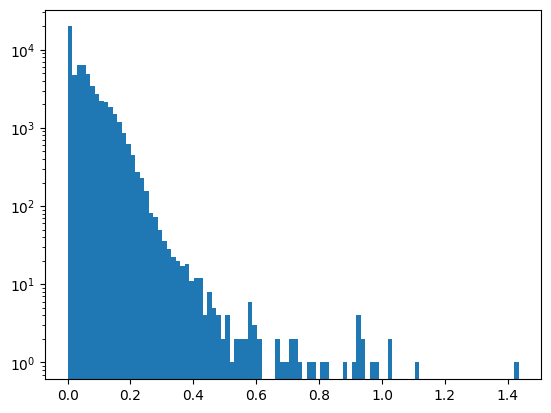

In [6]:
import matplotlib.pyplot as plt

for key in mean_error_dict:
    mae_map = rmse_dict[key]
    mae_values = mae_map.flatten()

    print("Min:", np.min(mae_values))
    print("Max:", np.max(mae_values))
    print("Mean:", np.mean(mae_values))
    print("Median:", np.median(mae_values))
    print("Std:", np.std(mae_values))
    for p in [50, 75, 90, 95, 99]:
        print(f"{p}th percentile:", np.percentile(mae_values, p))

    plt.hist(mae_values, bins=100)
    plt.yscale('log')  # if very skewed
    plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: collect all RMSE values into one big list/array
all_values = []

for key in rmse_dict:
    rmse_map = rmse_dict[key]        # shape (167, 360)
    rmse_values = rmse_map.flatten() # 1D
    all_values.append(rmse_values)

# Step 2: concatenate into a single array
all_values = np.concatenate(all_values)

